**SAPIANS** · SCC5819 · MÓDULO 04 — CONTRAFACTUAIS · MOLNAR, CAP. 15

# Contrafactuais — um passo a passo no modelo COVID

O módulo 03 fechou com um modelo local dizendo **quanto** cada feature
pesou nesta predição; nenhum dos três métodos anteriores sabia dizer o
que fazer a respeito. É essa a lacuna que este módulo ataca — e a
resposta deixa de ser um número por feature para ser um paciente inteiro.

[README do módulo](../README.md) · [companheiro: `cf_internals`](cf_internals.ipynb) · [o modelo do curso](../../00-dataset/MODEL.md) · [outline da aula](../lecture/outline.md)

---

O mesmo modelo dos módulos 00–03, e a pergunta invertida: em vez de "o
que pesou nesta predição?", **"qual é a menor mudança que muda a
predição?"** (Molnar, cap. 15; Wachter et al., 2018). A inversão muda o
papel das cercas: até aqui, paciente impossível era diagnóstico de
método doente; aqui a impossibilidade vira **restrição de busca** — e
ganha uma irmã que a `gate_impossible` não vê: a acionabilidade.

**O que você deve saber fazer ao final**

1. Formular a busca contrafactual como enumeração sobre movimentos
   declarados — e dizer quando exaustão vence busca genética.
2. Nomear os cinco critérios do cap. 15 (validade, proximidade,
   sparsidade, plausibilidade, diversidade) e apontar como cada um é
   operacionalizado — e medido — neste módulo.
3. Reconhecer o efeito Rashomon numa lista de contrafactuais válidos, e
   explicar por que o mais próximo pode ser inútil e o mais eficaz,
   absurdo.
4. Reportar honestamente o caso em que **não há** contrafactual — e por
   que essa é uma resposta do método, não uma falha dele.

Tudo que este notebook afirma é impresso por uma célula dele ou do
companheiro `cf_internals.ipynb` — que refaz a busca sem recorte, decompõe
a invalidez por cerca e testa a sensibilidade do limiar. Módulo novo:
não há era BCW.

In [1]:
%pip install -q xgboost scikit-learn matplotlib numpy pandas pyarrow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import inspect
import pathlib
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 120)
RANDOM_STATE = 42

REPO = pathlib.Path.cwd()
while REPO != REPO.parent and not (REPO / "tools" / "README.md").exists():
    REPO = REPO.parent
if not (REPO / "tools" / "README.md").exists():
    import tempfile
    REPO = pathlib.Path(tempfile.gettempdir()) / "interpretable-ml-lectures"
    if not REPO.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/wbendinelli/interpretable-ml-lectures.git",
                        str(REPO)], check=True)
sys.path.insert(0, str(REPO / "tools"))
import sapians as SP
import srag_60_model as M
import srag_70_explain as E

SP.aplicar()  # fontes empacotadas, tools/sapians.mplstyle e figures_generated/

g = M.load_gold(REPO / "modules/00-dataset/gold/gold_covid_obito_sample.parquet")
xgb, _logit = M.fit_models(g)

# o paciente deste módulo, POR REGRA: contrafactual pede alguém com o que
# perder — p mais próximo de 0,8 no teste, empate por gold_id
teste = g[g["split"] == "test"].reset_index(drop=True)
p_teste = M.predict_proba(xgb, teste)
ordem = np.lexsort((teste["gold_id"].to_numpy(), np.abs(p_teste - 0.8)))
alto = teste.iloc[ordem[0]].copy()
alto["p_obito"] = float(p_teste[ordem[0]])


def fmt(v):
    """o valor de uma feature como texto: número em português, categoria como está"""
    return SP.pt(v, 1) if isinstance(v, (int, float, np.floating)) else str(v)


print(f"paciente de alto risco: gold_id {int(alto['gold_id'])}  "
      f"p(óbito) {alto['p_obito']:.4f}")
print(f"  idade {alto['idade_anos']:.0f} | doses {int(alto['n_doses_antes_do_sintoma'])} | "
      f"meses desde mar/2020 {alto['meses_desde_mar2020']:.1f} | "
      f"fator de risco declarado: {bool(alto['fator_risc_portao'])}")
comorbs = [c for c in M.COMORBIDADES if str(alto[c]) == "sim"]
sintomas = [c for c in M.SINTOMAS if str(alto[c]) == "sim"]
print(f"  comorbidades sim: {comorbs}")
print(f"  sintomas sim: {sintomas}")

paciente de alto risco: gold_id 1266990  p(óbito) 0.7926
  idade 32 | doses 4 | meses desde mar/2020 46.1 | fator de risco declarado: True
  comorbidades sim: ['sind_down', 'neurologic', 'imunodepre', 'renal', 'out_morbi']
  sintomas sim: ['febre', 'tosse', 'dispneia', 'desc_resp', 'saturacao', 'dor_abd', 'fadiga']


## O que o método é

Do cap. 15, a definição em uma frase: *"A counterfactual explanation of
a prediction describes the smallest change to the feature values that
changes the prediction to a predefined output."* É o único método do
curso cuja saída é um **paciente hipotético**, não um número por feature
— e por isso é o método em que as cercas do módulo 00 param de ser
crítica e viram parte da resposta.

Wachter et al. (2018) formulam como otimização:

$$L(x') = \lambda \cdot \big(f(x') - y'\big)^2 + d(x, x')$$

| símbolo | o que é | aqui |
|---|---|---|
| $x'$ | o candidato a contrafactual | uma linha do Ouro com 1–2 campos trocados |
| $y'$ | a saída desejada | $p < 0{,}5$ (sobreviver, aos olhos do modelo) |
| $f(x') - y'$ | o termo de **validade** | a distância ao alvo, no eixo y do passo 2 |
| $d(x, x')$ | o termo de **proximidade** | Gower nas 40 features (a métrica que o cap. 15 recomenda para dado misto) |
| $\lambda$ | o câmbio entre os dois | **não precisamos dele** — ver abaixo |

**A escolha de configuração deste módulo, declarada:** nada de descida
de gradiente nem algoritmo genético. O espaço de busca cabe na memória
(113 mudanças simples, 6.129 pares), então a fronteira inteira da perda
de Wachter é **enumerada** — todo candidato avaliado, determinístico,
zero sementes — e o λ vira desnecessário: em vez de escolher um ponto da
troca validade×proximidade, mostramos a troca inteira (passo 2). DiCE
(Mothilal et al., 2020) não roda no stack pinado (numpy 2.x; decisão no
PR do pin); Dandl et al. (2020) resolvem com NSGA-II o que aqui se
resolve por exaustão — é o que faríamos se o espaço não coubesse.

Os **cinco critérios** do capítulo, e onde cada um mora neste notebook:

| critério (cap. 15) | operacionalização aqui |
|---|---|
| validade | cruzar $p = 0{,}5$ |
| proximidade | Gower ao paciente (passo 2 e tabelas do §6) |
| sparsidade | profundidade da busca: 1–2 mudanças por construção |
| plausibilidade | `gate_impossible` — a cerca derivável do módulo 00 |
| diversidade | o efeito Rashomon, medido no §4 |

E um sexto que o capítulo não formaliza e este módulo acrescenta:
**acionabilidade** (§5) — estar ao alcance de quem recebe a explicação.

## O paciente, e por que ele

Regra declarada: **p mais próximo de 0,8 no teste**, empate por
`gold_id` — não o paciente-regra dos módulos 01–03. O motivo é
geométrico: um contrafactual precisa de alguém **com o que perder**.
Para o paciente em $p = 0{,}5$, qualquer sopro cruza o limiar e toda a
busca degenera em trivialidade; para o de 0,8, cruzar exige mudanças
com conteúdo — e a pergunta "quais?" vira interessante.

Saiu um paciente de 32 anos — não um idoso —, com 4 doses, síndrome de
Down, doença neurológica, imunodepressão, doença renal e outras
morbidades, 46,1 meses depois de mar/2020. Nada disso é propriedade dos
dados: é uma regra de legibilidade, dita como tal.

## §1 — O espaço de busca, declarado

Movimentos por feature: idade em passos de 10, doses 0–6, meses em
passos de 6, booleanas nos dois valores, categóricas em todos os níveis.
`semana_epi` fica fora — é atrelada a `meses_desde_mar2020`, e mover uma
sem a outra fabricaria um calendário que não existe (a lição do módulo
03 aplicada ao **desenho** da busca, antes de medir).

**O que olhar**

- São 113 movimentos simples para este paciente, e o espaço é dominado
  por demografia (33), comorbidade (27) e sintoma (26): 86 dos 113 são
  coisas que ninguém decide ter.
- Contra elas, 7 movimentos de dose — a única família que uma pessoa
  escolhe. O §5 volta a essa conta.
- A busca corre **livre** primeiro, para ver o que o método *quer*; os
  filtros entram depois, um de cada vez, com contagem.

In [3]:
MOVES = {}
MOVES["idade_anos"] = [float(v) for v in range(0, 101, 10)]
MOVES["n_doses_antes_do_sintoma"] = [float(v) for v in range(0, 7)]
MOVES["meses_desde_mar2020"] = [float(v) for v in range(0, 59, 6)]
for c in M.BOOLEANAS:
    MOVES[c] = [False, True]
for c in M.CATEGORICAS:
    MOVES[c] = list(g[c].cat.categories)
# semana_epi fica fora: é atrelada a meses_desde_mar2020 — mover uma sem a
# outra fabricaria um calendário que não existe

# a que família cada uma das 40 features pertence — a tabela vive em
# tools/srag_60_model.py, uma só para os cinco módulos
GRUPO = dict(M.GRUPO_DE_FEATURE)


def candidatos_1(pac):
    out = []
    for c, vals in MOVES.items():
        for v in vals:
            if c in M.CATEGORICAS:
                if str(v) == str(pac[c]):
                    continue
            elif float(v) == float(pac[c]):
                continue
            out.append((c, v))
    return out


def aplicar(pac, lista_de_mudancas):
    """cada item é uma lista [(coluna, valor), ...]; devolve um frame."""
    linhas = []
    modelo_linha = {c: pac[c] for c in g.columns}
    for muds in lista_de_mudancas:
        linha = dict(modelo_linha)
        for c, v in muds:
            linha[c] = v
        linhas.append(linha)
    df = pd.DataFrame(linhas)
    return df.astype(g.dtypes)


c1 = candidatos_1(alto)
print(f"movimentos simples possíveis para este paciente: {len(c1)}")
n_grupos = pd.Series([GRUPO[c] for c, _ in c1]).value_counts()
print(n_grupos.to_string())

movimentos simples possíveis para este paciente: 113
demografia     33
comorbidade    27
sintoma        26
tempo          10
contexto       10
dose            7


## §2 — Profundidade 1: o que a busca livre quer

Uma mudança por vez, todas avaliadas num lote só. Na figura, a cor de
cada barra é a **família** da feature (`GRUPO_DE_FEATURE`, a mesma dos
cinco módulos) — uma taxonomia, não um juízo sobre o desfecho; o acento
terracota marca a única barra de que este texto fala.

**O que olhar**

- A melhor mudança do mundo, segundo o modelo, é `saturacao → nao` — a
  barra em terracota, da família **sintoma**: apagar do prontuário a
  saturação baixa, que é **consequência** da doença, não alavanca
  (p 0,793 → 0,571).
- A segunda é `idade → 10` em azul-escuro (**demografia**), dos 32 aos
  10 anos; a terceira recua o calendário para o mês 6 — cinza,
  **tempo** — e cai na cerca da pré-campanha.
- Em terracota clara (**comorbidade**), `imunodepre → desconhecido` e
  `out_morbi → desconhecido` entram nas dez: **apagar o registro**
  derruba a p quase tanto quanto curar a comorbidade — o modelo usando
  qualidade de documentação, a armadilha que o módulo 00 mediu.
- Na contagem, quem parte de um paciente real e muda um campo fabrica
  pouca ficção: 3,5% dos 113 caem na cerca, contra 30,6% do LIME pela
  mesma régua. E nenhuma mudança única cruza 0,5 sozinha.

as 10 mudanças simples que mais derrubam a predição:
  saturacao -> nao: p 0.793 -> 0.571 (sintoma)
  idade_anos -> 10,0: p 0.793 -> 0.571 (demografia)
  meses_desde_mar2020 -> 6,0: p 0.793 -> 0.574 (tempo)  [INVÁLIDO pela cerca]
  idade_anos -> 0,0: p 0.793 -> 0.604 (demografia)
  meses_desde_mar2020 -> 0,0: p 0.793 -> 0.611 (tempo)  [INVÁLIDO pela cerca]
  imunodepre -> nao: p 0.793 -> 0.622 (comorbidade)
  imunodepre -> desconhecido: p 0.793 -> 0.631 (comorbidade)
  desc_resp -> nao: p 0.793 -> 0.634 (sintoma)
  out_morbi -> nao: p 0.793 -> 0.658 (comorbidade)
  out_morbi -> desconhecido: p 0.793 -> 0.660 (comorbidade)

inválidos pela gate_impossible: 3.5% dos 113
mudanças simples que cruzam 0,5 e passam na cerca: 0


figura: figures_generated/cf_passo_1_busca_livre.png


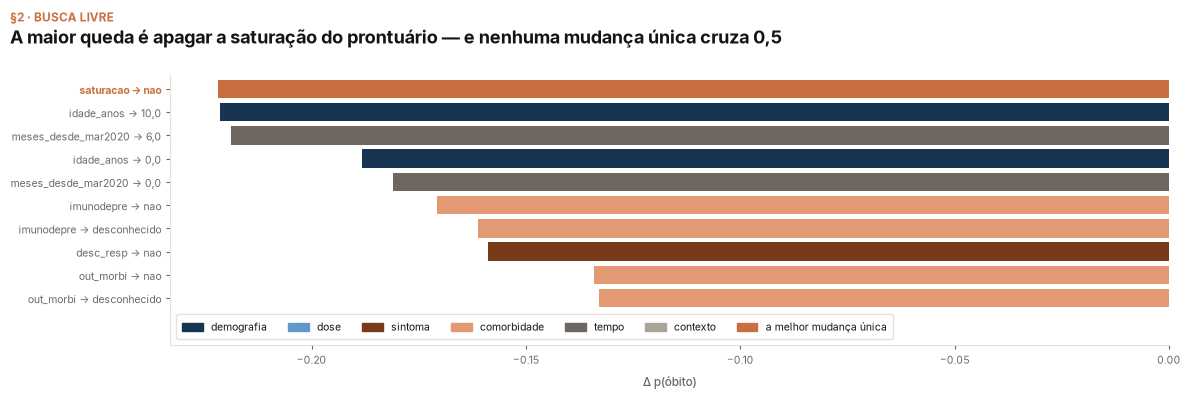

In [4]:
f1 = aplicar(alto, [[m] for m in c1])
p1 = M.predict_proba(xgb, f1)
delta = p1 - alto["p_obito"]
invalido1 = M.gate_impossible(f1).to_numpy()

melhores = np.argsort(delta)[:10]
print("as 10 mudanças simples que mais derrubam a predição:")
for i in melhores:
    c, v = c1[i]
    marca = "  [INVÁLIDO pela cerca]" if invalido1[i] else ""
    print(f"  {c} -> {fmt(v)}: p {alto['p_obito']:.3f} -> {p1[i]:.3f} ({GRUPO[c]}){marca}")
cruzam = ((p1 < 0.5) & ~invalido1).sum()
print(f"\ninválidos pela gate_impossible: {100 * invalido1.mean():.1f}% dos {len(c1)}")
print(f"mudanças simples que cruzam 0,5 e passam na cerca: {cruzam}")

# cor = FAMÍLIA da feature (SP.CORES_GRUPO: uma taxonomia, por isso tons das
# duas rampas e nenhuma cor semântica sólida); SP.TERRACOTA entra como ACENTO
# na única barra de que o texto fala — a melhor mudança única
fig, ax = plt.subplots(figsize=SP.FAIXA)
nomes = [f"{c1[i][0]} → {fmt(c1[i][1])}" for i in melhores][::-1]
vals = [delta[i] for i in melhores][::-1]
cores = [SP.CORES_GRUPO[GRUPO[c1[i][0]]] for i in melhores][::-1]
cores[-1] = SP.TERRACOTA
ax.barh(nomes, vals, color=cores)
ax.set_xlabel("Δ p(óbito)")
SP.sem_grade(ax)  # a grade do estilo é em y; sobre categorias ela riscaria as barras
acento = ax.get_yticklabels()[-1]
acento.set_color(SP.TERRACOTA)
acento.set_fontweight("bold")
handles = [plt.Rectangle((0, 0), 1, 1, color=v) for v in SP.CORES_GRUPO.values()]
handles.append(plt.Rectangle((0, 0), 1, 1, color=SP.TERRACOTA))
ax.set_ylim(-2.0, len(nomes) - 0.4)  # a faixa em branco embaixo é da legenda
ax.legend(handles, [*SP.CORES_GRUPO, "a melhor mudança única"],
          loc="lower left", ncol=7)
SP.titulo(
    fig,
    "A maior queda é apagar a saturação do prontuário — e nenhuma mudança única cruza 0,5",
    kicker="§2 · busca livre")
SP.salvar(fig, "cf_passo_1_busca_livre")
plt.show()

## §3 — Profundidade 2: a perda de Wachter, enumerada

Pares sobre os 60 melhores movimentos (o espaço completo, sem recorte,
está nos internals §1 — mesmo ótimo). O gráfico deste passo é a função
de perda de Wachter **vista por inteiro**: eixo x = proximidade (Gower),
eixo y = validade (p do candidato); cada ponto é um candidato avaliado.
Escolher λ é escolher um ponto desta nuvem; nós mostramos a nuvem.

**O que olhar**

- A leitura das cores é a do curso: **sálvia** = passa na cerca,
  **terracota** = impossível. Cada quadrado é um candidato sintético; o
  ✕ escuro em Gower 0 é o paciente, e o tracejado escuro é a fronteira
  p = 0,5 do modelo.
- O canto que interessa é o de baixo à esquerda — perto do paciente E
  abaixo de 0,5 — e ele é quase vazio: dos 1.691 pares avaliados, 68
  cruzam 0,5 passando na cerca, e o melhor chega a p 0,199.
- Quem mora nesse canto pede que ele volte ao mês 6 da pandemia sem
  nenhuma dose, ou que apague a saturação e vire uma criança de 10 anos.
  São pacientes que **podem existir** (a `gate_impossible` responde
  "isso existe?"); não são alcançáveis a partir de quem ele é (ela não
  foi desenhada para responder "dá para chegar lá?").
- Repare no primeiro par: recuar o calendário **sozinho** cai na cerca
  da pré-campanha (§2); recuá-lo **e** zerar as doses passa — o par
  escapa da cerca de que o movimento simples não escapava. Por que
  "curar" a imunodepressão também passa — ela volta na terceira história
  do §4 — é medido nos internals §3: o portão do funil é unidirecional
  no dado real.

pares avaliados: 1691 | inválidos: 6.5% | cruzam 0,5 válidos: 68

os 5 melhores contrafactuais 'válidos' — leia com atenção:
  meses_desde_mar2020 → 6,0 + n_doses_antes_do_sintoma → 0,0: p -> 0.199
  meses_desde_mar2020 → 0,0 + n_doses_antes_do_sintoma → 0,0: p -> 0.226
  saturacao → nao + idade_anos → 10,0: p -> 0.316
  saturacao → nao + idade_anos → 0,0: p -> 0.346
  idade_anos → 10,0 + imunodepre → nao: p -> 0.368
def gower_par(
    pac: pd.Series,
    frame: pd.DataFrame,
    num_cols,
    cat_cols,
    faixas: dict | None = None,
) -> np.ndarray:
    """Gower do paciente a CADA linha do frame — a régua do módulo 04.

    Mesma família de métrica que `gower_ao_vizinho`, outra pergunta: ali o
    vizinho real mais próximo de um ponto fabricado; aqui o custo `d` de
    cada candidato a contrafactual, o termo de proximidade da perda de
    Wachter. O paciente entra como escalar (`float(pac[c])`,
    `str(pac[c])`), nunca como frame de uma linha — reindexar mudaria os
    dtypes. Sem `

figura: figures_generated/cf_passo_2_fronteira.png


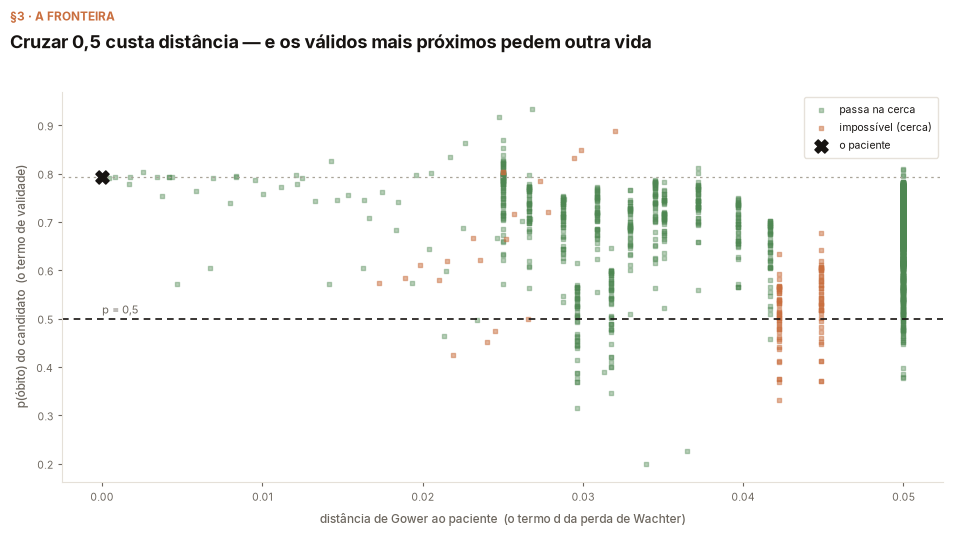

In [5]:
top60 = list(np.argsort(delta)[:60])
pares = [[c1[i], c1[j]] for a, i in enumerate(top60)
         for j in top60[a + 1:] if c1[i][0] != c1[j][0]]
f2 = aplicar(alto, pares)
p2 = M.predict_proba(xgb, f2)
invalido2 = M.gate_impossible(f2).to_numpy()
ok2 = (p2 < 0.5) & ~invalido2
print(f"pares avaliados: {len(pares)} | inválidos: {100 * invalido2.mean():.1f}% | "
      f"cruzam 0,5 válidos: {ok2.sum()}")
print("\nos 5 melhores contrafactuais 'válidos' — leia com atenção:")
mostrados = 0
for i in np.argsort(p2):
    if not ok2[i]:
        continue
    desc = " + ".join(f"{c} → {fmt(v)}" for c, v in pares[i])
    print(f"  {desc}: p -> {p2[i]:.3f}")
    mostrados += 1
    if mostrados >= 5:
        break

NUM_G = list(M.NUMERICAS)
CAT_G = list(M.CATEGORICAS) + list(M.BOOLEANAS)
FAIXAS = E.faixas_de(g, NUM_G)

# a mesma família de métrica do módulo 01 (que media ao vizinho real), aqui
# par a par — e, como lá, o núcleo é compartilhado e impresso:
print(inspect.getsource(E.gower_par))


def gower_par(pac, frame):
    return E.gower_par(pac, frame, NUM_G, CAT_G, faixas=FAIXAS)


g1, g2 = gower_par(alto, f1), gower_par(alto, f2)
# a semântica de classe do curso: SAGE = possível/válido, TERRACOTA = impossível;
# quadrado = candidato sintético e ✕ = o paciente explicado; a fronteira p=0,5 no
# traço reservado a ela (L_FRONTEIRA) e a p do paciente no traço de andaime (L_REF)
fig, ax = plt.subplots(figsize=SP.SLOT)
todos_p = np.concatenate([p1, p2])
todos_g = np.concatenate([g1, g2])
todos_inv = np.concatenate([invalido1, invalido2])
ax.scatter(todos_g[~todos_inv], todos_p[~todos_inv], s=8, alpha=0.4,
           color=SP.SAGE, marker=SP.MARCADOR_SINTETICO, label="passa na cerca")
ax.scatter(todos_g[todos_inv], todos_p[todos_inv], s=8, alpha=0.5,
           color=SP.TERRACOTA, marker=SP.MARCADOR_SINTETICO,
           label="impossível (cerca)")
ax.axhline(0.5, **SP.L_FRONTEIRA)
ax.axhline(alto["p_obito"], **SP.L_REF)
ax.scatter([0.0], [alto["p_obito"]], s=90, color=SP.ESCURO, zorder=5,
           marker=SP.MARCADOR_PACIENTE, label="o paciente")
ax.text(0.0, 0.505, f"p = {SP.pt(0.5, 1)}", ha="left", va="bottom",
        fontsize=8, color=SP.CINZA)
ax.set_xlabel("distância de Gower ao paciente  (o termo d da perda de Wachter)")
ax.set_ylabel("p(óbito) do candidato  (o termo de validade)")
SP.sem_grade(ax)
ax.legend()
SP.titulo(
    fig,
    "Cruzar 0,5 custa distância — e os válidos mais próximos pedem outra vida",
    kicker="§3 · a fronteira")
SP.salvar(fig, "cf_passo_2_fronteira")
plt.show()

## §4 — O efeito Rashomon: três histórias válidas que se contradizem

O cap. 15 avisa: *"For each instance, you will usually find multiple
counterfactual explanations (Rashomon effect)"* — múltiplas explicações
igualmente válidas contando histórias contraditórias sobre como chegar
ao desfecho. Aqui isso não é um risco teórico: são 68 candidatos
válidos cruzando 0,5. A célula escolhe, por regra gulosa, três com
conjuntos de features **disjuntos** — três receitas sem um ingrediente
em comum.

**O que olhar**

- As três levam a p de 0,793 a 0,199, 0,316 e 0,452 — todas válidas,
  nenhuma compartilhando uma única feature com as outras.
- Cada tabela sozinha parece *a* explicação; as três juntas mostram que
  "a explicação" não existe — existe um cardápio, e a escolha de qual
  servir é de quem explica, não do método.
- O critério de **diversidade** do capítulo é exatamente pedir o
  cardápio de uma vez (é o que o DiCE otimiza); a resposta honesta
  continua sendo mostrar que ele existe.

In [6]:
validos = [i for i in np.argsort(p2) if ok2[i]]
historias = []
for i in validos:
    feats = {c for c, _ in pares[i]}
    if all(feats.isdisjoint(fs) for _, fs in historias):
        historias.append((i, feats))
    if len(historias) == 3:
        break
print(f"3 histórias com features DISJUNTAS, escolhidas dos {int(ok2.sum())} "
      f"contrafactuais válidos (gula por menor p):\n")
for n, (i, _) in enumerate(historias, 1):
    tab = pd.DataFrame(
        [(c, fmt(alto[c]), fmt(v)) for c, v in pares[i]],
        columns=["feature", "paciente", "contrafactual"])
    print(f"história {n}  —  p: {alto['p_obito']:.3f} → {p2[i]:.3f}")
    print(tab.to_string(index=False))
    print()
print("as três são 'válidas', as três contradizem umas às outras sobre o que")
print("importa — recue o calendário para o mês 6 e zere as doses; apague a")
print("saturação e vire uma criança de 10 anos; cure a imunodepressão e o")
print("desconforto respiratório.")
print("É o efeito Rashomon do cap. 15: qual história você contaria ao paciente?")

3 histórias com features DISJUNTAS, escolhidas dos 68 contrafactuais válidos (gula por menor p):

história 1  —  p: 0.793 → 0.199
                 feature paciente contrafactual
     meses_desde_mar2020     46,1           6,0
n_doses_antes_do_sintoma        4           0,0

história 2  —  p: 0.793 → 0.316
   feature paciente contrafactual
 saturacao      sim           nao
idade_anos     32,1          10,0

história 3  —  p: 0.793 → 0.452
   feature paciente contrafactual
imunodepre      sim           nao
 desc_resp      sim           nao

as três são 'válidas', as três contradizem umas às outras sobre o que
importa — recue o calendário para o mês 6 e zere as doses; apague a
saturação e vire uma criança de 10 anos; cure a imunodepressão e o
desconforto respiratório.
É o efeito Rashomon do cap. 15: qual história você contaria ao paciente?


## §5 — As alavancas reais

O que uma pessoa (ou uma política de saúde) de fato controla neste
vetor: o histórico vacinal **antes do sintoma** — doses para cima, nunca
para baixo — e a declaração dele. Idade, sexo, comorbidades registradas,
sintomas (consequência, não causa) e o calendário não são alavancas.

**O que olhar**

- Primeiro o paciente do módulo: os dois candidatos acionáveis que ele
  tem (subir para 5 ou 6 doses) deixam a p em 0,793, onde ela já estava
  — nenhum cruza, e nenhum sequer move a previsão na terceira casa (o
  módulo 05 §5 mede a atribuição positiva das doses: grupos
  priorizados, não causa).
- Depois o teste inteiro: dos 624 pacientes com p ≥ 0,5, 30,3% têm
  contrafactual acionável e 69,7% não têm.
- Na figura, uma série só e por isso azul; o rótulo em terracota é o
  achado: a fração **cai com o risco** — 35% na banda 0,5–0,6, 15% na
  0,6–0,7 e **0% no 0,7+**, onde nenhum dos 19 pacientes tem saída.
  Quem mais precisaria de uma é exatamente quem não tem nenhuma ao
  alcance. Um método que só sabe dizer "faça X" precisa saber dizer
  "não há X".

candidatos acionáveis do paciente de alto risco: 2
  n_doses_antes_do_sintoma → 5,0: p -> 0.793
  n_doses_antes_do_sintoma → 6,0: p -> 0.793
algum cruza 0,5? False — o melhor chega a 0.793



pacientes do teste com p >= 0,5: 624 de 16142


com contrafactual ACIONÁVEL que cruza 0,5: 189 (30.3%)
sem nada ao alcance que mude a previsão: 435 (69.7%)

fração com contrafactual acionável, por banda de risco:
             mean  count
banda                   
0,5–0,6  0.350410    488
0,6–0,7  0.153846    117
0,7+     0.000000     19


figura: figures_generated/cf_passo_3_painel.png


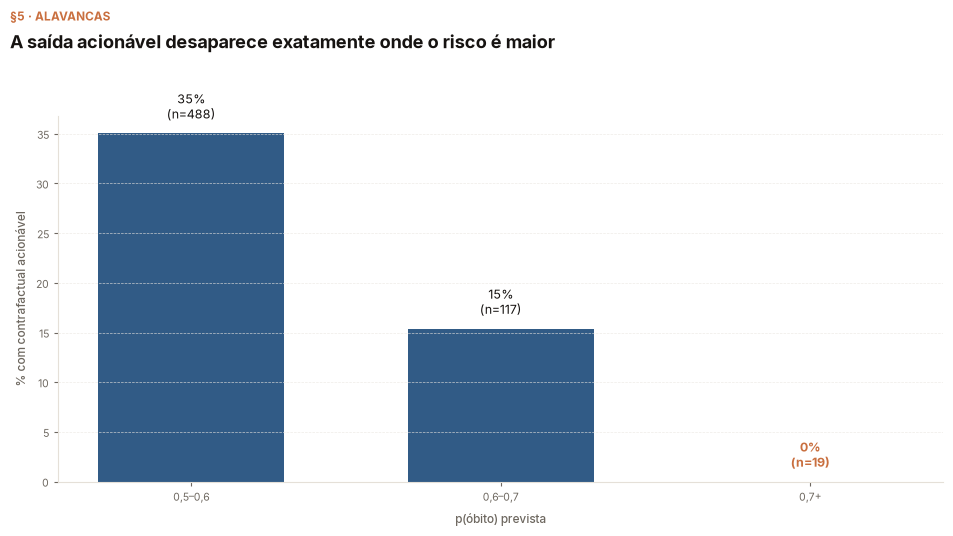

In [7]:
ALAVANCAS = ("n_doses_antes_do_sintoma", "vacina_covid_declarada")


def candidatos_acionaveis(pac):
    """doses só para CIMA (o passado vacinal poderia ter sido maior, nunca
    menor) e a declaração junto; nada mais é alcançável por decisão."""
    d0 = int(pac["n_doses_antes_do_sintoma"])
    cand = [[("n_doses_antes_do_sintoma", float(d))] for d in range(d0 + 1, 7)]
    if not bool(pac["vacina_covid_declarada"]):
        cand += [[("vacina_covid_declarada", True)]]
        cand += [[("n_doses_antes_do_sintoma", float(d)),
                  ("vacina_covid_declarada", True)] for d in range(d0 + 1, 7)]
    return cand


cand_alto = candidatos_acionaveis(alto)
fa = aplicar(alto, cand_alto)
pa = M.predict_proba(xgb, fa)
print(f"candidatos acionáveis do paciente de alto risco: {len(cand_alto)}")
for muds, p in zip(cand_alto, pa):
    desc = " + ".join(f"{c} → {fmt(v)}" for c, v in muds)
    print(f"  {desc}: p -> {p:.3f}")
print(f"algum cruza 0,5? {bool((pa < 0.5).any())} — o melhor chega a {pa.min():.3f}")

# o mesmo teste para TODO paciente de alto risco do split de teste
p_todos = M.predict_proba(xgb, teste)
alto_risco = teste[p_todos >= 0.5].reset_index(drop=True)
print(f"\npacientes do teste com p >= 0,5: {len(alto_risco)} de {len(teste)}")

blocos, indices = [], []
for k in range(len(alto_risco)):
    pac_k = alto_risco.iloc[k]
    cand_k = candidatos_acionaveis(pac_k)
    if cand_k:
        blocos.append(aplicar(pac_k, cand_k))
        indices.extend([k] * len(cand_k))
lote = pd.concat(blocos, ignore_index=True)
p_lote = M.predict_proba(xgb, lote)
flip = pd.Series(p_lote < 0.5).groupby(np.asarray(indices)).any()
com_cf = int(flip.sum())
print(f"com contrafactual ACIONÁVEL que cruza 0,5: {com_cf} "
      f"({100 * com_cf / len(alto_risco):.1f}%)")
print(f"sem nada ao alcance que mude a previsão: {len(alto_risco) - com_cf} "
      f"({100 * (1 - com_cf / len(alto_risco)):.1f}%)")

p_ar = p_todos[p_todos >= 0.5]
bandas = pd.cut(p_ar, [0.5, 0.6, 0.7, 1.0], labels=["0,5–0,6", "0,6–0,7", "0,7+"])
tab = pd.DataFrame({"banda": bandas, "flip": flip.reindex(range(len(alto_risco)),
                                                          fill_value=False).to_numpy()})
resumo = tab.groupby("banda", observed=True)["flip"].agg(["mean", "count"])
print("\nfração com contrafactual acionável, por banda de risco:")
print(resumo.to_string())

# uma série só, nenhuma comparação de classe: SP.AZUL, a série primária. O
# rótulo da banda de maior risco vai em TERRACOTA — é o achado que o texto aponta
fig, ax = plt.subplots(figsize=SP.SLOT)
ax.bar(resumo.index.astype(str), 100 * resumo["mean"], color=SP.AZUL, width=0.6)
for x, (m, n) in enumerate(zip(resumo["mean"], resumo["count"])):
    e_acento = x == len(resumo) - 1
    ax.text(x, 100 * m + 1.5, f"{SP.pct(m, 0)}\n(n={SP.pt_int(n)})", ha="center",
            fontsize=9, fontweight="bold" if e_acento else "normal",
            color=SP.TERRACOTA if e_acento else SP.ESCURO)
ax.set_ylabel("% com contrafactual acionável")
ax.set_xlabel("p(óbito) prevista")
SP.titulo(
    fig,
    "A saída acionável desaparece exatamente onde o risco é maior",
    kicker="§5 · alavancas")
SP.salvar(fig, "cf_passo_3_painel")
plt.show()

## §6 — Três filtros, três tabelas

Os melhores candidatos de cada busca, no formato do capítulo — feature,
valor do paciente, valor do contrafactual — com p, Gower e sparsidade no
cabeçalho.

**O que olhar**

- A ordem de Gower. O candidato **mais próximo** de todos é o acionável
  (0,0042) — e não cruza; o "melhor" contrafactual válido está a 0,0339,
  oito vezes mais longe e absurdo como prescrição.
- A perda de Wachter, sozinha, escolheria o absurdo: a proximidade não
  codifica mutabilidade, e a plausibilidade (a cerca) não codifica
  alcançabilidade.
- *Existir, estar perto, estar ao alcance* — três perguntas, e só a
  terceira é sobre o paciente real.

In [8]:
def tabela_cf(titulo, muds, p_novo, frame_1linha):
    print(f"{titulo}  —  p: {alto['p_obito']:.3f} → {p_novo:.3f} | "
          f"Gower {gower_par(alto, frame_1linha)[0]:.4f} | "
          f"{len(muds)} mudança(s)")
    tab = pd.DataFrame([(c, fmt(alto[c]), fmt(v)) for c, v in muds],
                       columns=["feature", "paciente", "contrafactual"])
    print(tab.to_string(index=False))
    print()


melhor_1 = int(np.argmin(p1))
val2 = np.where(ok2)[0]
melhor_2 = int(val2[np.argmin(p2[val2])])
melhor_a = int(np.argmin(pa))

tabela_cf("melhor mudança única (busca livre)", [c1[melhor_1]],
          float(p1[melhor_1]), f1.iloc[[melhor_1]])
tabela_cf("melhor par válido (busca livre)", pares[melhor_2],
          float(p2[melhor_2]), f2.iloc[[melhor_2]])
tabela_cf("melhor acionável (não cruza)", cand_alto[melhor_a],
          float(pa[melhor_a]), fa.iloc[[melhor_a]])

print("o candidato MAIS PRÓXIMO é o acionável — e não cruza; os livres, quase")
print("tão próximos, são absurdos como prescrição. Proximidade não codifica")
print("mutabilidade, e a gate_impossible não codifica acionabilidade. Três")
print("filtros distintos: existir, estar perto, estar ao alcance.")

melhor mudança única (busca livre)  —  p: 0.793 → 0.571 | Gower 0.0250 | 1 mudança(s)
  feature paciente contrafactual
saturacao      sim           nao

melhor par válido (busca livre)  —  p: 0.793 → 0.199 | Gower 0.0339 | 2 mudança(s)
                 feature paciente contrafactual
     meses_desde_mar2020     46,1           6,0
n_doses_antes_do_sintoma        4           0,0

melhor acionável (não cruza)  —  p: 0.793 → 0.793 | Gower 0.0042 | 1 mudança(s)
                 feature paciente contrafactual
n_doses_antes_do_sintoma        4           5,0

o candidato MAIS PRÓXIMO é o acionável — e não cruza; os livres, quase
tão próximos, são absurdos como prescrição. Proximidade não codifica
mutabilidade, e a gate_impossible não codifica acionabilidade. Três
filtros distintos: existir, estar perto, estar ao alcance.


## O que o livro diz

Do Molnar, [cap. 15](https://christophm.github.io/interpretable-ml-book/counterfactual.html),
sobre a força do método:

> "The interpretation of counterfactual explanations is very clear (...)
> There are no additional assumptions and no magic in the background."

Verdade — e este módulo mediu o preço da clareza: sem uma lista de
alavancas, o "smallest change" sem mágica devolve *"apague do prontuário
a saturação baixa"* e, logo atrás, *"volte a ter 10 anos"*. A ausência de suposições no método empurra as suposições para o
desenho do espaço de busca, onde elas ficam visíveis (e é aí que devem
ficar).

| do capítulo | neste módulo |
|---|---|
| os 5 critérios (validade, proximidade, sparsidade, plausibilidade, diversidade) | operacionalizados um a um — tabela do objetivo, §§2–4 |
| efeito Rashomon como limitação | medido: 68 válidos, 3 histórias disjuntas impressas (§4) |
| Wachter: perda λ·validade + distância | enumerada por inteiro — o passo 2 é a nuvem da perda, sem λ |
| Dandl et al. 2020: NSGA-II multiobjetivo | citado como o caminho quando a enumeração não cabe; aqui cabe (internals §1: ótimo confirmado sem recorte) |
| DiCE (Mothilal et al. 2020): diversidade otimizada | não roda no stack pinado — declarado, com a decisão no PR do pin |

Crédito a quem pertence: a formulação é de Wachter; os critérios e o
Rashomon, do capítulo; a **acionabilidade como sexto filtro medido** — e
o achado de que ela escasseia exatamente onde o risco cresce — é a
contribuição deste módulo.

## Fechamento — a resposta honesta

A pergunta invertida tem três respostas possíveis, e o módulo mediu as
três: *há um contrafactual acionável* (30,3% do alto risco do teste);
*há contrafactuais válidos, mas nenhum ao seu alcance* (69,7% — e todos
os 19 da banda de maior risco); *o que a busca livre encontra é absurdo com
carimbo de válido* (o Rashomon do §4).

O que carregar:

1. Exaustão em lote custa milissegundos quando o espaço é declarado —
   e cobertura completa com zero sementes vale mais que sofisticação
   estocástica em espaço pequeno.
2. Os cinco critérios do capítulo não bastam sem o sexto: a lista de
   alavancas é uma decisão sobre o mundo, não uma propriedade do modelo
   — e é a única parte da explicação que olha para o paciente real.
3. "Não há X ao seu alcance" é uma resposta do método — a mais
   importante que ele sabe dar, e a que nenhuma perda otimizada devolve
   sozinha.

O módulo 05 fecha o curso pelo outro lado: em vez de buscar a mudança,
**atribuir** a predição inteira — exatamente — e verificar se a doença
dos vizinhos impossíveis alcança até lá (alcança: 23,1%).

**Referências**

- Molnar, C. — *Interpretable Machine Learning*, 3ª ed., [cap. 15
  (Counterfactual Explanations)](https://christophm.github.io/interpretable-ml-book/counterfactual.html).
- Wachter, Mittelstadt & Russell (2018) — *Counterfactual Explanations
  without Opening the Black Box*, Harvard JOLT 31(2)
  ([arXiv:1711.00399](https://arxiv.org/abs/1711.00399)): a perda que o
  §3 enumera por inteiro.
- Dandl, Molnar, Binder & Bischl (2020) — *Multi-Objective Counterfactual
  Explanations* ([arXiv:2004.11165](https://arxiv.org/abs/2004.11165)):
  NSGA-II, o caminho quando a enumeração não cabe.
- Mothilal, Sharma & Tan (2020) — *Explaining Machine Learning
  Classifiers through Diverse Counterfactual Explanations* (DiCE),
  FAT\* 2020: a diversidade como objetivo; citado e não executado.
- Base, modelo, pacientes e cercas: módulo 00
  ([MODEL.md](../../00-dataset/MODEL.md)).
- Stack pinado deste caderno: xgboost 3.4.1, scikit-learn 1.9.0,
  pandas 2.3.3, numpy 2.4.6, matplotlib 3.11.1 (`requirements.lock`).